In [1]:
import json

# 打开文件并读取数据
with open('fine-tuned-models/nllb-200-distilled-600M/zh2ko_1101/trainer_state.json', 'r') as f:
    data = json.load(f)

data

{'best_metric': 0.01578390598297119,
 'best_model_checkpoint': 'autodl-tmp/nllb-200-distilled-600M/zh2ko/checkpoint-180000',
 'epoch': 2.9028980598964633,
 'global_step': 180000,
 'is_hyper_param_search': False,
 'is_local_process_zero': True,
 'is_world_process_zero': True,
 'log_history': [{'epoch': 0.16,
   'learning_rate': 8.056348476784879e-06,
   'loss': 3.8897,
   'step': 10000},
  {'epoch': 0.16,
   'eval_loss': 0.044559821486473083,
   'eval_runtime': 635.5311,
   'eval_samples_per_second': 24.392,
   'eval_steps_per_second': 24.392,
   'step': 10000},
  {'epoch': 0.32,
   'learning_rate': 1.6119954198719502e-05,
   'loss': 0.0372,
   'step': 20000},
  {'epoch': 0.32,
   'eval_loss': 0.02811146154999733,
   'eval_runtime': 631.5033,
   'eval_samples_per_second': 24.548,
   'eval_steps_per_second': 24.548,
   'step': 20000},
  {'epoch': 0.48,
   'learning_rate': 2.4181947199509732e-05,
   'loss': 0.0285,
   'step': 30000},
  {'epoch': 0.48,
   'eval_loss': 0.024000100791454315,

In [2]:
import pandas as pd

df = pd.DataFrame(data["log_history"])
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.16,0.000008,3.8897,10000,NaN,NaN,NaN,NaN
1,0.16,NaN,NaN,10000,0.044560,635.5311,24.392,24.392
2,0.32,0.000016,0.0372,20000,NaN,NaN,NaN,NaN
3,0.32,NaN,NaN,20000,0.028111,631.5033,24.548,24.548
4,0.48,0.000024,0.0285,30000,NaN,NaN,NaN,NaN
5,0.48,NaN,NaN,30000,0.024000,628.1591,24.678,24.678
6,0.65,0.000032,0.0246,40000,NaN,NaN,NaN,NaN
7,0.65,NaN,NaN,40000,0.021790,627.5556,24.702,24.702
8,0.81,0.000040,0.0229,50000,NaN,NaN,NaN,NaN
9,0.81,NaN,NaN,50000,0.020521,624.1920,24.835,24.835


In [3]:
df.set_index('epoch', inplace=True)
df = df.groupby(level=0).first()
df.reset_index(inplace=True)
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.16,0.000008,3.8897,10000,0.044560,635.5311,24.392,24.392
1,0.32,0.000016,0.0372,20000,0.028111,631.5033,24.548,24.548
2,0.48,0.000024,0.0285,30000,0.024000,628.1591,24.678,24.678
3,0.65,0.000032,0.0246,40000,0.021790,627.5556,24.702,24.702
4,0.81,0.000040,0.0229,50000,0.020521,624.1920,24.835,24.835
5,0.97,0.000048,0.0223,60000,0.019945,622.3392,24.909,24.909
6,1.13,0.000049,0.0194,70000,0.019336,636.5988,24.351,24.351
7,1.29,0.000048,0.0175,80000,0.018803,637.1630,24.330,24.330
8,1.45,0.000047,0.0180,90000,0.017863,639.6144,24.236,24.236
9,1.61,0.000047,0.0178,100000,0.017512,646.5224,23.978,23.978


In [4]:
df = df.iloc[1:]
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
1,0.32,0.000016,0.0372,20000,0.028111,631.5033,24.548,24.548
2,0.48,0.000024,0.0285,30000,0.024000,628.1591,24.678,24.678
3,0.65,0.000032,0.0246,40000,0.021790,627.5556,24.702,24.702
4,0.81,0.000040,0.0229,50000,0.020521,624.1920,24.835,24.835
5,0.97,0.000048,0.0223,60000,0.019945,622.3392,24.909,24.909
6,1.13,0.000049,0.0194,70000,0.019336,636.5988,24.351,24.351
7,1.29,0.000048,0.0175,80000,0.018803,637.1630,24.330,24.330
8,1.45,0.000047,0.0180,90000,0.017863,639.6144,24.236,24.236
9,1.61,0.000047,0.0178,100000,0.017512,646.5224,23.978,23.978
10,1.77,0.000046,0.0171,110000,0.017066,644.8234,24.041,24.041


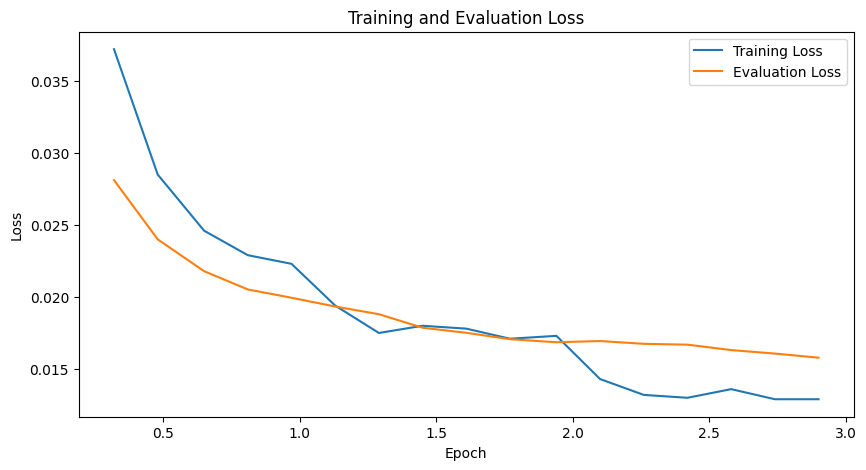

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['loss'], label='Training Loss')
plt.plot(df['epoch'], df['eval_loss'], label='Evaluation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.show()